# Statistics of inputs vs distance

In [1]:
%reset
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.cm as cm
import os
import plotly.graph_objects as go
from scipy.stats import sem

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


# Useful functions

In [2]:
# -----------------------------
# Compute orientation difference
# -----------------------------

def circular_diff_ori(a, b):
    """Signed circular difference in radians for orientations (mod π). Result in (-π/2, π/2]."""
    diff = (a - b + np.pi/2) % np.pi - np.pi/2
    return diff


# ---------------------------
# Helper
# ---------------------------
def binned_mean_sem(x, y, bins):
    digitized = np.digitize(x, bins)
    means, errors = [], []
    for i in range(1, len(bins)):
        vals = y[digitized == i]
        if len(vals) > 0:
            means.append(np.nanmean(vals))
            errors.append(sem(vals, nan_policy='omit'))
        else:
            means.append(np.nan)
            errors.append(np.nan)
    return np.array(means), np.array(errors)

def binned_mean_sem_weighted(x, y, w, bins):
    digitized = np.digitize(x, bins)
    means, errors = [], []

    for i in range(1, len(bins)):
        vals = y[digitized == i]
        weights = w[digitized == i]

        if len(vals) > 0 and np.sum(weights) > 0:
            # Normalize weights to sum to 1
            weights = weights / np.sum(weights)

            # Weighted mean
            mean = np.sum(weights * vals)
            means.append(mean)

            # Weighted variance and SEM
            variance = np.sum(weights * (vals - mean)**2)
            sem_w = np.sqrt(variance / len(vals))
            errors.append(sem_w)
        else:
            means.append(np.nan)
            errors.append(np.nan)

    return np.array(means), np.array(errors)


def plot_with_sem(ax, x, y, yerr, label, n=None, color=None):
    label_str = f"{label} (n={n})" if n is not None else label
    line, = ax.plot(x, y, label=label_str, color=color)
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.3, color=line.get_color())

# ---------------------------------------
# Circular mean helper
# ---------------------------------------
def orientation_mean(angles_rad, n_bootstrap=1000, seed=None):
    rng = np.random.default_rng(seed)
    angles_rad = np.asarray(angles_rad)

    if len(angles_rad) == 1:
        return angles_rad[0], angles_rad[0], angles_rad[0]

    def compute_mean(angles):
        return np.angle(np.mean(np.exp(2j * angles))) / 2

    mean_angle = compute_mean(angles_rad)
    means = np.array([
        compute_mean(rng.choice(angles_rad, size=len(angles_rad), replace=True))
        for _ in range(n_bootstrap)
    ])
    return mean_angle, np.percentile(means, 25), np.percentile(means, 75)

def binned_circular_mean(x, y, bins):
    valid = (~np.isnan(x)) & (~np.isnan(y))
    x, y = x[valid], y[valid]

    digitized = np.digitize(x, bins)
    means, lows, highs = [], [], []
    for i in range(1, len(bins)):
        vals = y[digitized == i]
        if len(vals) > 0:
            m, lo, hi = orientation_mean(vals)
        else:
            m, lo, hi = np.nan, np.nan, np.nan
        means.append(m)
        lows.append(lo)
        highs.append(hi)
    return np.array(means), np.array(lows), np.array(highs)


def orientation_mean_weighted(angles_rad, weights, n_bootstrap=1000, seed=None):
    rng = np.random.default_rng(seed)
    angles_rad = np.asarray(angles_rad)
    weights = np.asarray(weights)

    if len(angles_rad) == 1:
        return angles_rad[0], angles_rad[0], angles_rad[0]

    def compute_weighted_mean(angles, weights):
        vec = weights * np.exp(2j * angles)
        return np.angle(np.sum(vec) / np.sum(weights)) / 2

    mean_angle = compute_weighted_mean(angles_rad, weights)

    # Bootstrap
    means = np.array([
        compute_weighted_mean(
            rng.choice(angles_rad, size=len(angles_rad), replace=True),
            rng.choice(weights, size=len(weights), replace=True)
        )
        for _ in range(n_bootstrap)
    ])

    return mean_angle, np.percentile(means, 25), np.percentile(means, 75)


def binned_circular_mean_weighted(x, angles, weights, bins):
    valid = (~np.isnan(x)) & (~np.isnan(angles)) & (~np.isnan(weights))
    x, angles, weights = x[valid], angles[valid], weights[valid]

    digitized = np.digitize(x, bins)
    means, lows, highs = [], [], []

    for i in range(1, len(bins)):
        bin_mask = digitized == i
        if np.any(bin_mask):
            m, lo, hi = orientation_mean_weighted(angles[bin_mask], weights[bin_mask])
        else:
            m, lo, hi = np.nan, np.nan, np.nan
        means.append(m)
        lows.append(lo)
        highs.append(hi)

    return np.array(means), np.array(lows), np.array(highs)

# Load and process data

In [3]:
# Choose layer
neuron_layer = "full_features_all_L5_neurons.csv"
csv_path = os.path.join("/media/DATA1/CK/python_script/MicronsBinder_04/data/data_processed/neurons_5P_7148/", neuron_layer)

# read
df = pd.read_csv(csv_path, low_memory=False)

# quick print
print("shape:", df.shape)
print("columns:", len(df.columns))
display(df.head())


shape: (8398951, 33)
columns: 33


,synapse_id,size,pre_pt_root_id,node_id,distance_from_soma,branch_order,dendrites,segments,type,post_pt_root_id,...,cc_abs_pre,pref_ori_post,pref_dir_post,gOSI_post,gDSI_post,cc_abs_post,pref_ori_diff_wrapped,pref_dir_diff_wrapped,strat_axon_pre,strat_dendrite_post
0,309395306,3164.0,864691135538129266,1452,86.327792,1,8,1,3.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,none
1,289161294,3632.0,864691135456102346,1572,38.228342,3,4,5,3.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
2,284849188,3200.0,864691135947139208,290,206.340992,5,2,10,4.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
3,292863493,2596.0,864691136634153334,1,10.996328,1,1,1,2.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
4,273012453,1480.0,864691135746546163,925,170.929374,5,3,8,3.0,864691134885137402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none


# Data Distribution

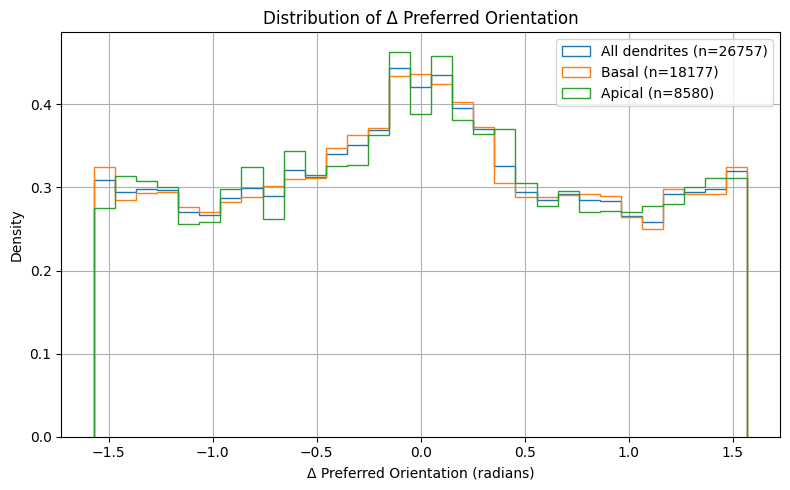

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- minimal filters for THIS plot ---
df0 = df.copy()

# drop autapses (safe even if none)
df0 = df0[df0["pre_pt_root_id"] != df0["post_pt_root_id"]]

# keep dendritic synapses only (Basal+Apical)
df0 = df0[df0["type"].isin([3, 3.0, 4, 4.0])]

# must have wrapped delta orientation
df0 = df0[df0["pref_ori_diff_wrapped"].notna()]

# groups
delta_all   = df0["pref_ori_diff_wrapped"].to_numpy()
delta_basal = df0.loc[df0["type"].isin([3, 3.0]), "pref_ori_diff_wrapped"].to_numpy()
delta_apic  = df0.loc[df0["type"].isin([4, 4.0]), "pref_ori_diff_wrapped"].to_numpy()

# bins like his (covers [-pi/2, pi/2])
bins = np.linspace(-np.pi/2, np.pi/2, 32)

plt.figure(figsize=(8, 5))
plt.hist(delta_all,   bins=bins, density=True, histtype="step", label=f"All dendrites (n={len(delta_all)})")
plt.hist(delta_basal, bins=bins, density=True, histtype="step", label=f"Basal (n={len(delta_basal)})")
plt.hist(delta_apic,  bins=bins, density=True, histtype="step", label=f"Apical (n={len(delta_apic)})")

plt.xlabel("Δ Preferred Orientation (radians)")
plt.ylabel("Density")
plt.title("Distribution of Δ Preferred Orientation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


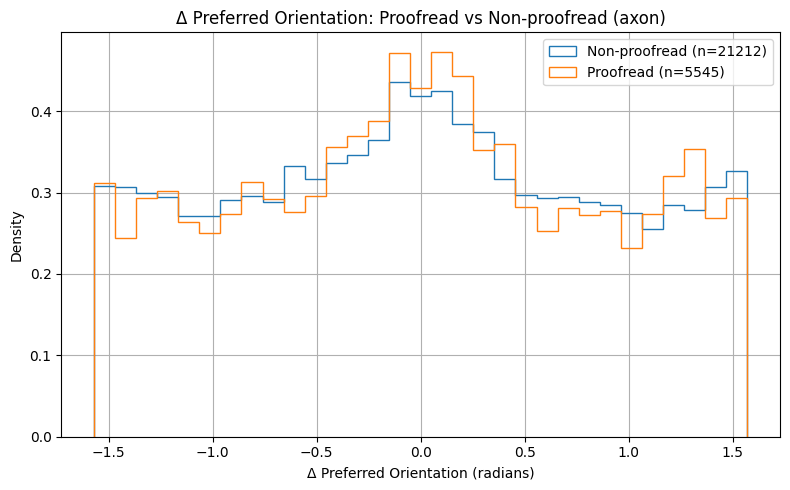

strat_axon_pre unique (top): strat_axon_pre
none                       21097
axon_partially_extended     4545
axon_fully_extended          567
axon_interareal              433
nan                          115
Name: count, dtype: int64


In [5]:
# --- proofread vs non-proofread (within df0) ---
# Proofread = strat_axon_pre is not NaN AND not the literal "none"
mask_proof = (
    df0["strat_axon_pre"].notna()
    & (df0["strat_axon_pre"].astype(str).str.lower() != "none")
)

delta_proof = df0.loc[mask_proof, "pref_ori_diff_wrapped"].to_numpy()
delta_non   = df0.loc[~mask_proof, "pref_ori_diff_wrapped"].to_numpy()

# Plot overlay
bins = np.linspace(-np.pi/2, np.pi/2, 32)

plt.figure(figsize=(8, 5))
plt.hist(delta_non,   bins=bins, density=True, histtype="step", label=f"Non-proofread (n={len(delta_non)})")
plt.hist(delta_proof, bins=bins, density=True, histtype="step", label=f"Proofread (n={len(delta_proof)})")

plt.xlabel("Δ Preferred Orientation (radians)")
plt.ylabel("Density")
plt.title("Δ Preferred Orientation: Proofread vs Non-proofread (axon)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# sanity check: what values are in strat_axon_pre?
print("strat_axon_pre unique (top):", df0["strat_axon_pre"].astype(str).str.lower().value_counts().head(10))


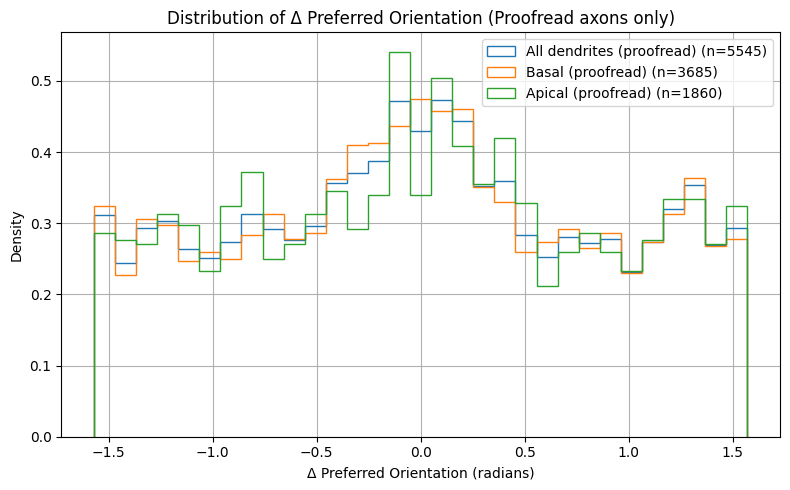

In [6]:
# --- Basal vs Apical within PROOFREAD only ---
df_proof = df0[mask_proof].copy()

delta_all_proof   = df_proof["pref_ori_diff_wrapped"].to_numpy()
delta_basal_proof = df_proof.loc[df_proof["type"].isin([3, 3.0]), "pref_ori_diff_wrapped"].to_numpy()
delta_apic_proof  = df_proof.loc[df_proof["type"].isin([4, 4.0]), "pref_ori_diff_wrapped"].to_numpy()

bins = np.linspace(-np.pi/2, np.pi/2, 32)

plt.figure(figsize=(8, 5))
plt.hist(delta_all_proof,   bins=bins, density=True, histtype="step",
         label=f"All dendrites (proofread) (n={len(delta_all_proof)})")
plt.hist(delta_basal_proof, bins=bins, density=True, histtype="step",
         label=f"Basal (proofread) (n={len(delta_basal_proof)})")
plt.hist(delta_apic_proof,  bins=bins, density=True, histtype="step",
         label=f"Apical (proofread) (n={len(delta_apic_proof)})")

plt.xlabel("Δ Preferred Orientation (radians)")
plt.ylabel("Density")
plt.title("Distribution of Δ Preferred Orientation (Proofread axons only)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Size vs Distance for Proofreading Status

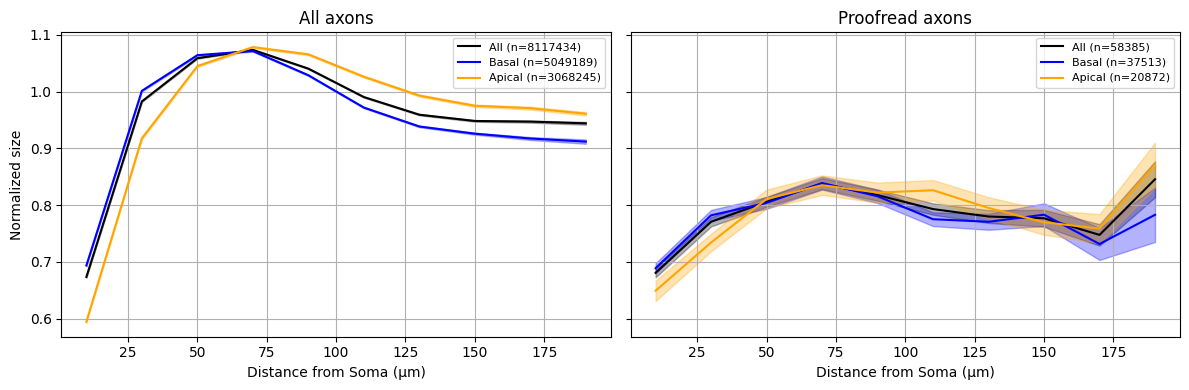

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

bins = np.arange(0, 201, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

def binned_mean_sem(x, y, bins):
    digitized = np.digitize(x, bins)
    means, errors = [], []
    for i in range(1, len(bins)):
        vals = y[digitized == i]
        if len(vals) > 0:
            means.append(np.nanmean(vals))
            errors.append(sem(vals, nan_policy="omit"))
        else:
            means.append(np.nan)
            errors.append(np.nan)
    return np.array(means), np.array(errors)

def plot_group(ax, dfg, label, color):
    x = dfg["distance_from_soma"].to_numpy()
    y = dfg["size"].to_numpy()
    m, e = binned_mean_sem(x, y, bins)
    ax.plot(bin_centers, m, label=f"{label} (n={len(dfg)})", color=color)
    ax.fill_between(bin_centers, m-e, m+e, alpha=0.3, color=color)

# ---- base filtering for this analysis ----
d0 = df.copy()
d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]          # no autapses
d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]                      # dendrites only (Basal/Apical)
d0 = d0[d0["distance_from_soma"].notna() & d0["size"].notna()]   # needs x,y

# normalize size like Sanzeni
d0["size"] = d0["size"] / d0["size"].mean()

# masks
mask_proof = d0["strat_axon_pre"].notna() & (d0["strat_axon_pre"].astype(str).str.lower() != "none")

panels = [
    ("All axons", d0),
    ("Proofread axons", d0[mask_proof]),
]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, (title, dpanel) in zip(axs, panels):
    plot_group(ax, dpanel, "All", "black")
    plot_group(ax, dpanel[dpanel["type"].isin([3, 3.0])], "Basal", "blue")
    plot_group(ax, dpanel[dpanel["type"].isin([4, 4.0])], "Apical", "orange")

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("Distance from Soma (µm)")
    ax.legend(fontsize=8)

axs[0].set_ylabel("Normalized size")

plt.tight_layout()
plt.show()


# abs delta pref ori vs Distance for Proofreading Status

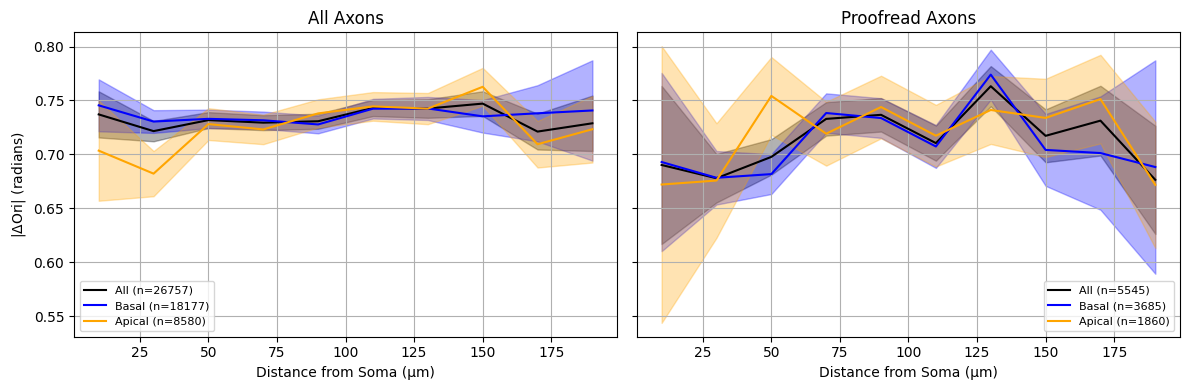

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# --- bins ---
bins = np.arange(0, 201, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

def binned_mean_sem(x, y, bins):
    digitized = np.digitize(x, bins)
    means, errors = [], []
    for i in range(1, len(bins)):
        vals = y[digitized == i]
        if len(vals) > 0:
            means.append(np.nanmean(vals))
            errors.append(sem(vals, nan_policy="omit"))
        else:
            means.append(np.nan)
            errors.append(np.nan)
    return np.array(means), np.array(errors)

def plot_group(ax, dfg, label, color, ycol):
    # counts should reflect valid y values
    dfg2 = dfg[dfg[ycol].notna() & dfg["distance_from_soma"].notna()]
    x = dfg2["distance_from_soma"].to_numpy()
    y = dfg2[ycol].to_numpy()
    m, e = binned_mean_sem(x, y, bins)
    ax.plot(bin_centers, m, label=f"{label} (n={len(dfg2)})", color=color)
    ax.fill_between(bin_centers, m - e, m + e, alpha=0.3, color=color)

# ---- base filtering for THIS analysis ----
d0 = df.copy()

# remove autapses
d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]

# dendrites only (Basal+Apical)
d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]

# define abs delta ori
d0["abs_delta_ori"] = d0["pref_ori_diff_wrapped"].abs()

# proofread axon mask (exclude NaN and 'none')
mask_proof = (
    d0["strat_axon_pre"].notna()
    & (d0["strat_axon_pre"].astype(str).str.lower() != "none")
)

panels = [
    ("All Axons", d0),
    ("Proofread Axons", d0[mask_proof]),
]

colors = {"All": "black", "Basal": "blue", "Apical": "orange"}

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, (title, dpanel) in zip(axs, panels):
    plot_group(ax, dpanel, "All", colors["All"], ycol="abs_delta_ori")
    plot_group(ax, dpanel[dpanel["type"].isin([3, 3.0])], "Basal", colors["Basal"], ycol="abs_delta_ori")
    plot_group(ax, dpanel[dpanel["type"].isin([4, 4.0])], "Apical", colors["Apical"], ycol="abs_delta_ori")

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("Distance from Soma (µm)")
    ax.legend(fontsize=8)

axs[0].set_ylabel(r"$|\Delta \mathrm{Ori}|$ (radians)")

plt.tight_layout()
plt.show()


In [9]:
print("All dendrite synapses:", len(d0))
print("All with ori diff:", d0["abs_delta_ori"].notna().sum())
print("Proofread with ori diff:", d0.loc[mask_proof, "abs_delta_ori"].notna().sum())


All dendrite synapses: 8117434
All with ori diff: 26757
Proofread with ori diff: 5545


# Weighted abs delta pref ori vs Distance for Proofreading Status

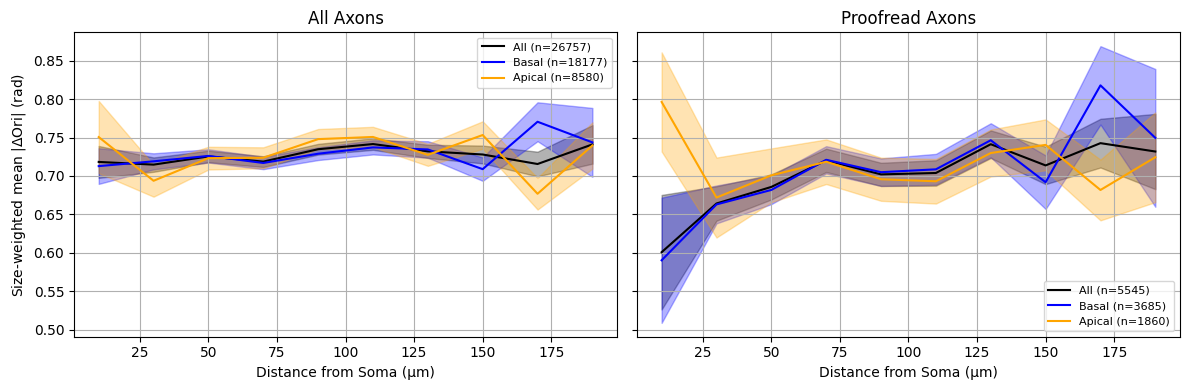

In [10]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.arange(0, 201, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

def binned_mean_sem_weighted(x, y, w, bins):
    digitized = np.digitize(x, bins)
    means, errors = [], []

    for i in range(1, len(bins)):
        vals = y[digitized == i]
        weights = w[digitized == i]

        ok = (~np.isnan(vals)) & (~np.isnan(weights))
        vals = vals[ok]
        weights = weights[ok]

        if len(vals) > 0 and np.sum(weights) > 0:
            weights = weights / np.sum(weights)
            mean = np.sum(weights * vals)
            means.append(mean)

            variance = np.sum(weights * (vals - mean) ** 2)
            sem_w = np.sqrt(variance / len(vals))
            errors.append(sem_w)
        else:
            means.append(np.nan)
            errors.append(np.nan)

    return np.array(means), np.array(errors)

def plot_group_weighted(ax, dfg, label, color, ycol, wcol):
    dfg2 = dfg[
        dfg["distance_from_soma"].notna()
        & dfg[ycol].notna()
        & dfg[wcol].notna()
    ].copy()

    x = dfg2["distance_from_soma"].to_numpy()
    y = dfg2[ycol].to_numpy()
    w = dfg2[wcol].to_numpy()

    m, e = binned_mean_sem_weighted(x, y, w, bins)
    ax.plot(bin_centers, m, label=f"{label} (n={len(dfg2)})", color=color)
    ax.fill_between(bin_centers, m - e, m + e, alpha=0.3, color=color)

# ---- base filtering ----
d0 = df.copy()
d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]     # no autapses
d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]                 # dendrites only

# y and weights
d0["abs_delta_ori"] = d0["pref_ori_diff_wrapped"].abs()
d0["w_size"] = d0["size"] / d0["size"].mean()              # size weights (normalized)

# proofread axon mask
mask_proof = (
    d0["strat_axon_pre"].notna()
    & (d0["strat_axon_pre"].astype(str).str.lower() != "none")
)

panels = [
    ("All Axons", d0),
    ("Proofread Axons", d0[mask_proof]),
]
colors = {"All": "black", "Basal": "blue", "Apical": "orange"}

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, (title, dpanel) in zip(axs, panels):
    plot_group_weighted(ax, dpanel, "All", colors["All"], "abs_delta_ori", "w_size")
    plot_group_weighted(ax, dpanel[dpanel["type"].isin([3, 3.0])], "Basal", colors["Basal"], "abs_delta_ori", "w_size")
    plot_group_weighted(ax, dpanel[dpanel["type"].isin([4, 4.0])], "Apical", colors["Apical"], "abs_delta_ori", "w_size")

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("Distance from Soma (µm)")
    ax.legend(fontsize=8)

axs[0].set_ylabel(r"Size-weighted mean $|\Delta \mathrm{Ori}|$ (rad)")
plt.tight_layout()
plt.show()


# look at strength of synapses vs delta pref ori in each bin

/tmp/ipykernel_960391/2870807400.py:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  errors.append(sem(vals, nan_policy="omit"))


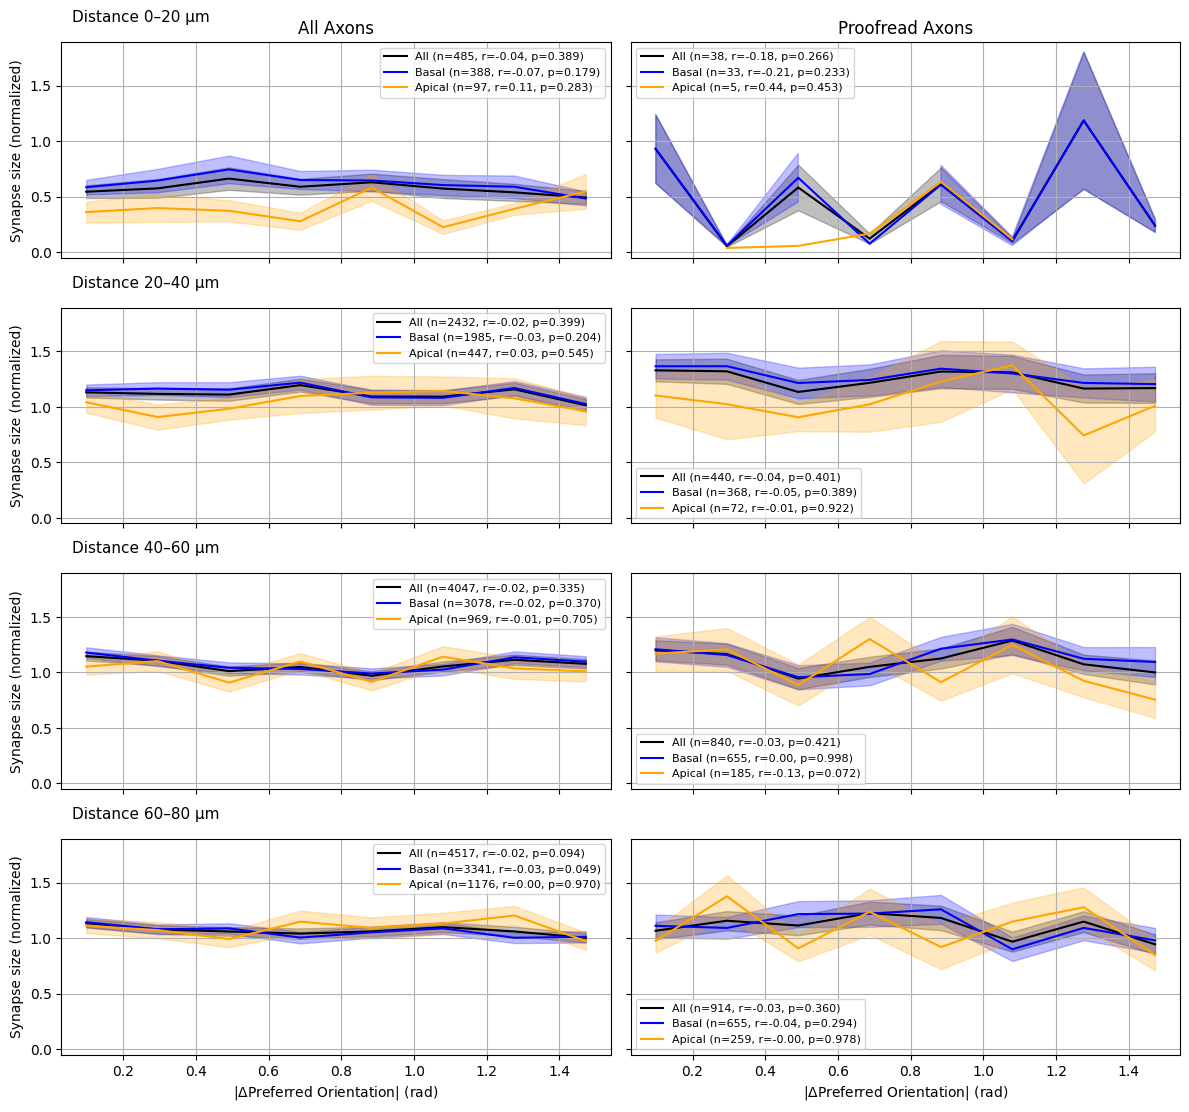

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, pearsonr

def binned_mean_sem(x, y, bins):
    """Return mean and SEM of y in bins of x."""
    x = np.asarray(x)
    y = np.asarray(y)
    digitized = np.digitize(x, bins)
    means, errors = [], []
    for i in range(1, len(bins)):
        vals = y[digitized == i]
        if len(vals) > 0:
            means.append(np.nanmean(vals))
            errors.append(sem(vals, nan_policy="omit"))
        else:
            means.append(np.nan)
            errors.append(np.nan)
    return np.array(means), np.array(errors)

def corr_label(x, y, name, n):
    """Pearson r,p on finite pairs; return legend label."""
    x = np.asarray(x); y = np.asarray(y)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return f"{name} (n={n}, r=nan, p=nan)"
    r, p = pearsonr(x[ok], y[ok])
    return f"{name} (n={n}, r={r:.2f}, p={p:.3f})"

def plot_strength_vs_delta_by_distance(
    df,
    distance_bins=((0, 20), (20, 40), (40, 60), (60, 80), (80, 100), (100, 120)),
    delta_bins=np.linspace(0, np.pi/2, 9),  # bins on |Δori|
    use_proofread=True,
    normalize_size=True,
):
    # ---- base cleaning (only what we need) ----
    d0 = df.copy()
    d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]     # no autapses
    d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]                 # dendrites only
    d0 = d0[d0["distance_from_soma"].notna() & d0["size"].notna()]
    d0 = d0[d0["pref_ori_diff_wrapped"].notna()]               # need Δori

    # y and x
    if normalize_size:
        d0["size_plot"] = d0["size"] / d0["size"].mean()
    else:
        d0["size_plot"] = d0["size"]

    d0["abs_delta_ori"] = d0["pref_ori_diff_wrapped"].abs()

    # proofread axon mask
    mask_proof = (
        d0["strat_axon_pre"].notna()
        & (d0["strat_axon_pre"].astype(str).str.lower().str.strip() != "none")
    )

    panels = [("All Axons", d0)]
    if use_proofread:
        panels.append(("Proofread Axons", d0[mask_proof]))

    # plot grid
    nrows = len(distance_bins)
    ncols = len(panels)
    fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 2.8*nrows), sharex=True, sharey=True)

    # make axs always 2D
    if nrows == 1 and ncols == 1:
        axs = np.array([[axs]])
    elif nrows == 1:
        axs = np.array([axs])
    elif ncols == 1:
        axs = np.array([[ax] for ax in axs])

    colors = {"All": "black", "Basal": "blue", "Apical": "orange"}
    x_centers = (delta_bins[:-1] + delta_bins[1:]) / 2

    for r, (dmin, dmax) in enumerate(distance_bins):
        for c, (title, dpanel) in enumerate(panels):
            ax = axs[r, c]

            # distance slice
            ds = dpanel[(dpanel["distance_from_soma"] >= dmin) & (dpanel["distance_from_soma"] < dmax)]

            # helper to plot one group
            def do_group(label, subdf, color):
                x = subdf["abs_delta_ori"].to_numpy()
                y = subdf["size_plot"].to_numpy()

                # correlation uses raw points
                n = len(subdf)
                leg = corr_label(x, y, label, n=n)

                # binned curve
                m, e = binned_mean_sem(x, y, delta_bins)
                ax.plot(x_centers, m, color=color, label=leg)
                ax.fill_between(x_centers, m - e, m + e, color=color, alpha=0.25)

            # plot All/Basal/Apical
            do_group("All", ds, colors["All"])
            do_group("Basal", ds[ds["type"].isin([3, 3.0])], colors["Basal"])
            do_group("Apical", ds[ds["type"].isin([4, 4.0])], colors["Apical"])

            # titles/labels
            if r == 0:
                ax.set_title(title)
            if c == 0:
                ax.set_ylabel("Synapse size" + (" (normalized)" if normalize_size else ""))
            if r == nrows - 1:
                ax.set_xlabel(r"$|\Delta \mathrm{Preferred\ Orientation}|$ (rad)")

            ax.grid(True)
            ax.legend(fontsize=8, loc="best")

            # row annotation (distance bin) as a suptitle-like line
            if c == 0:
                ax.text(
                    0.02, 1.08, f"Distance {dmin}–{dmax} µm",
                    transform=ax.transAxes, fontsize=11, ha="left", va="bottom"
                )

    plt.tight_layout()
    plt.show()

# ---- run it ----
plot_strength_vs_delta_by_distance(
    df,
    distance_bins=((0,20), (20,40), (40,60), (60,80)),  # adjust as you like
    delta_bins=np.linspace(0, np.pi/2, 9),
    use_proofread=True,
    normalize_size=True,
)


/tmp/ipykernel_960391/3417296144.py:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  errors.append(sem(vals, nan_policy="omit"))


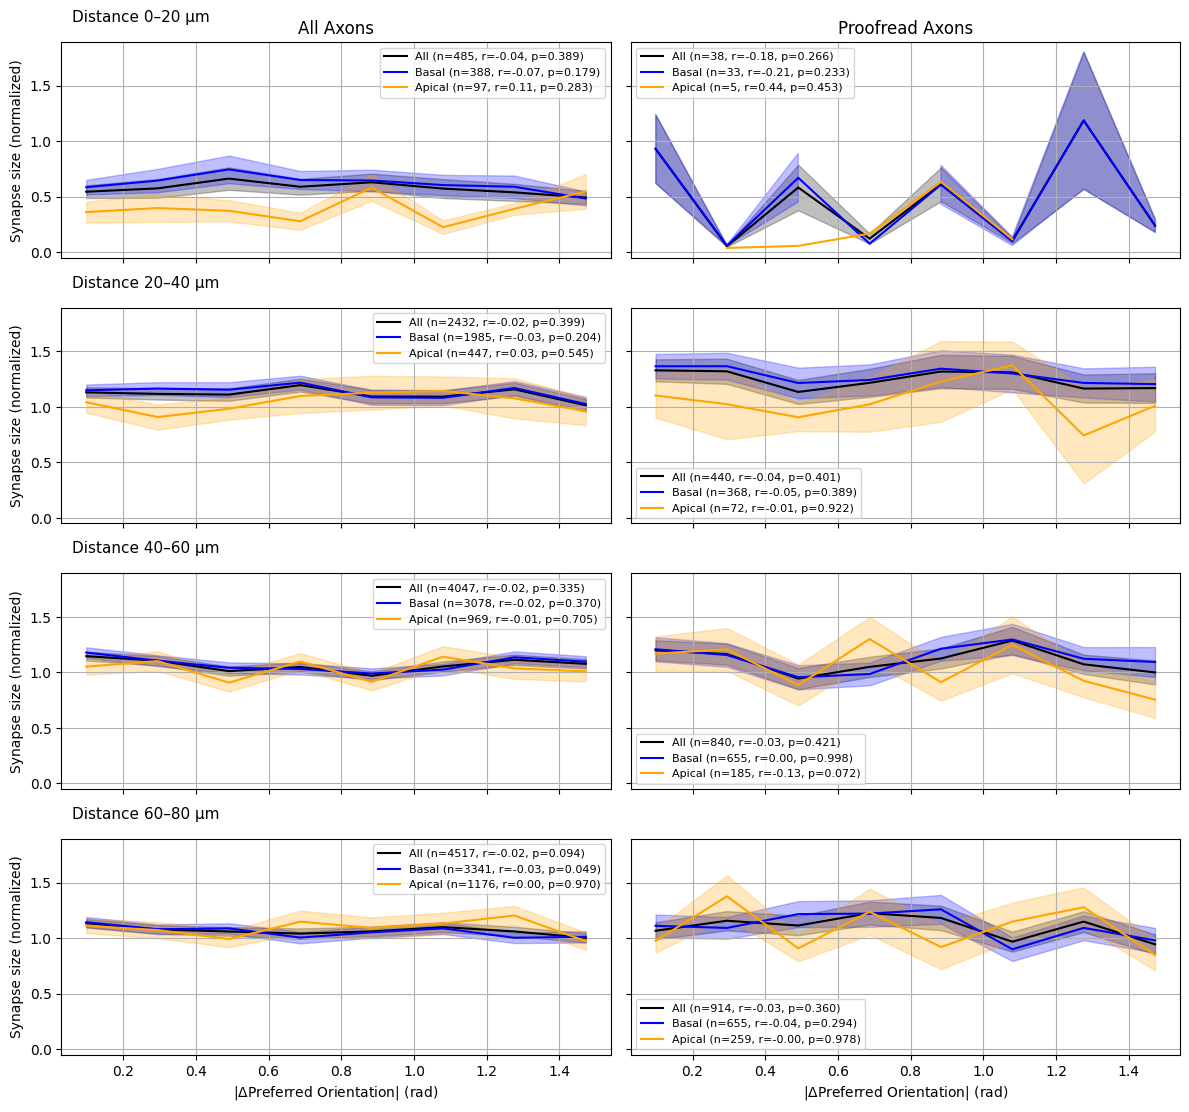

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, pearsonr

def binned_mean_sem(x, y, bins):
    """Return mean and SEM of y in bins of x."""
    x = np.asarray(x)
    y = np.asarray(y)
    digitized = np.digitize(x, bins)
    means, errors = [], []
    for i in range(1, len(bins)):
        vals = y[digitized == i]
        if len(vals) > 0:
            means.append(np.nanmean(vals))
            errors.append(sem(vals, nan_policy="omit"))
        else:
            means.append(np.nan)
            errors.append(np.nan)
    return np.array(means), np.array(errors)

def corr_label(x, y, name, n):
    """Pearson r,p on finite pairs; return legend label."""
    x = np.asarray(x); y = np.asarray(y)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return f"{name} (n={n}, r=nan, p=nan)"
    r, p = pearsonr(x[ok], y[ok])
    return f"{name} (n={n}, r={r:.2f}, p={p:.3f})"

def plot_strength_vs_delta_by_distance(
    df,
    distance_bins=((0, 25), (25, 50), (50, 80), (80, 100), (100, 150), (150, np.inf)),
    delta_bins=np.linspace(0, np.pi/2, 9),  # bins on |Δori|
    use_proofread=True,
    normalize_size=True,
):
    # ---- base cleaning (only what we need) ----
    d0 = df.copy()
    d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]     # no autapses
    d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]                 # dendrites only
    d0 = d0[d0["distance_from_soma"].notna() & d0["size"].notna()]
    d0 = d0[d0["pref_ori_diff_wrapped"].notna()]               # need Δori

    # y and x
    if normalize_size:
        d0["size_plot"] = d0["size"] / d0["size"].mean()
    else:
        d0["size_plot"] = d0["size"]

    d0["abs_delta_ori"] = d0["pref_ori_diff_wrapped"].abs()

    # proofread axon mask
    mask_proof = (
        d0["strat_axon_pre"].notna()
        & (d0["strat_axon_pre"].astype(str).str.lower().str.strip() != "none")
    )

    panels = [("All Axons", d0)]
    if use_proofread:
        panels.append(("Proofread Axons", d0[mask_proof]))

    # plot grid
    nrows = len(distance_bins)
    ncols = len(panels)
    fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 2.8*nrows), sharex=True, sharey=True)

    # make axs always 2D
    if nrows == 1 and ncols == 1:
        axs = np.array([[axs]])
    elif nrows == 1:
        axs = np.array([axs])
    elif ncols == 1:
        axs = np.array([[ax] for ax in axs])

    colors = {"All": "black", "Basal": "blue", "Apical": "orange"}
    x_centers = (delta_bins[:-1] + delta_bins[1:]) / 2

    for r, (dmin, dmax) in enumerate(distance_bins):
        for c, (title, dpanel) in enumerate(panels):
            ax = axs[r, c]

            # distance slice
            ds = dpanel[(dpanel["distance_from_soma"] >= dmin) & (dpanel["distance_from_soma"] < dmax)]

            # helper to plot one group
            def do_group(label, subdf, color):
                x = subdf["abs_delta_ori"].to_numpy()
                y = subdf["size_plot"].to_numpy()

                # correlation uses raw points
                n = len(subdf)
                leg = corr_label(x, y, label, n=n)

                # binned curve
                m, e = binned_mean_sem(x, y, delta_bins)
                ax.plot(x_centers, m, color=color, label=leg)
                ax.fill_between(x_centers, m - e, m + e, color=color, alpha=0.25)

            # plot All/Basal/Apical
            do_group("All", ds, colors["All"])
            do_group("Basal", ds[ds["type"].isin([3, 3.0])], colors["Basal"])
            do_group("Apical", ds[ds["type"].isin([4, 4.0])], colors["Apical"])

            # titles/labels
            if r == 0:
                ax.set_title(title)
            if c == 0:
                ax.set_ylabel("Synapse size" + (" (normalized)" if normalize_size else ""))
            if r == nrows - 1:
                ax.set_xlabel(r"$|\Delta \mathrm{Preferred\ Orientation}|$ (rad)")

            ax.grid(True)
            ax.legend(fontsize=8, loc="best")

            # row annotation (distance bin) as a suptitle-like line
            if c == 0:
                ax.text(
                    0.02, 1.08, f"Distance {dmin}–{dmax} µm",
                    transform=ax.transAxes, fontsize=11, ha="left", va="bottom"
                )

    plt.tight_layout()
    plt.show()

# ---- run it ----
plot_strength_vs_delta_by_distance(
    df,
    distance_bins=((0,20), (20,40), (40,60), (60,80)),  # adjust as you like
    delta_bins=np.linspace(0, np.pi/2, 9),
    use_proofread=True,
    normalize_size=True,
)


# Circular mean

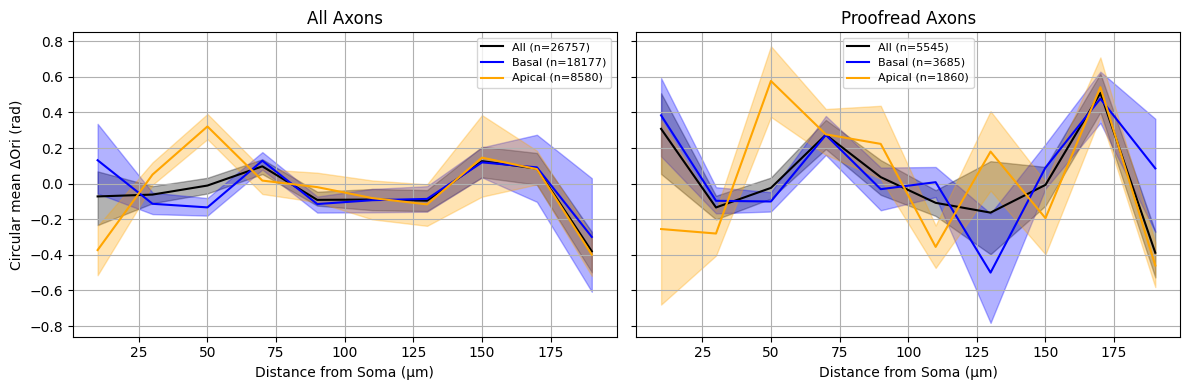

In [13]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.arange(0, 201, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

# ---- base filtering ----
d0 = df.copy()
d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]
d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]
d0 = d0[d0["distance_from_soma"].notna()]

# signed delta ori (prefer your wrapped if it is signed)
d0["delta_ori"] = d0["pref_ori_diff_wrapped"]  # should be signed in [-pi/2, pi/2]
d0 = d0[d0["delta_ori"].notna()]

# proofread axon mask
mask_proof = (
    d0["strat_axon_pre"].notna()
    & (d0["strat_axon_pre"].astype(str).str.lower().str.strip() != "none")
)

panels = [("All Axons", d0), ("Proofread Axons", d0[mask_proof])]
colors = {"All": "black", "Basal": "blue", "Apical": "orange"}

def plot_circ(ax, dfg, label, color):
    vals = dfg["delta_ori"].dropna().to_numpy()
    m, lo, hi = binned_circular_mean(dfg["distance_from_soma"].to_numpy(), vals, bins)
    ax.plot(bin_centers, m, label=f"{label} (n={len(vals)})", color=color)
    ax.fill_between(bin_centers, lo, hi, alpha=0.3, color=color)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, (title, dpanel) in zip(axs, panels):
    plot_circ(ax, dpanel, "All", colors["All"])
    plot_circ(ax, dpanel[dpanel["type"].isin([3, 3.0])], "Basal", colors["Basal"])
    plot_circ(ax, dpanel[dpanel["type"].isin([4, 4.0])], "Apical", colors["Apical"])

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("Distance from Soma (µm)")
    ax.legend(fontsize=8)

axs[0].set_ylabel("Circular mean ΔOri (rad)")
plt.tight_layout()
plt.show()


In [14]:
d0["pref_ori_diff_wrapped"].min(), d0["pref_ori_diff_wrapped"].max()


(np.float64(-1.5701977464102068), np.float64(1.5704926535897936))

In [15]:
bins = np.arange(0, 201, 20)

def bin_counts(dfg, col="delta_ori"):
    digitized = np.digitize(dfg["distance_from_soma"].to_numpy(), bins)
    return [np.sum((digitized == i) & dfg[col].notna()) for i in range(1, len(bins))]

d0 = d0.copy()
d0["delta_ori"] = d0["pref_ori_diff_wrapped"]

print("All counts:", bin_counts(d0))
print("Basal counts:", bin_counts(d0[d0["type"].isin([3,3.0])]))
print("Apical counts:", bin_counts(d0[d0["type"].isin([4,4.0])]))


All counts: [np.int64(485), np.int64(2432), np.int64(4047), np.int64(4517), np.int64(4522), np.int64(3862), np.int64(3021), np.int64(1751), np.int64(795), np.int64(366)]
Basal counts: [np.int64(388), np.int64(1985), np.int64(3078), np.int64(3341), np.int64(3212), np.int64(2649), np.int64(1990), np.int64(996), np.int64(325), np.int64(116)]
Apical counts: [np.int64(97), np.int64(447), np.int64(969), np.int64(1176), np.int64(1310), np.int64(1213), np.int64(1031), np.int64(755), np.int64(470), np.int64(250)]


# Modulus

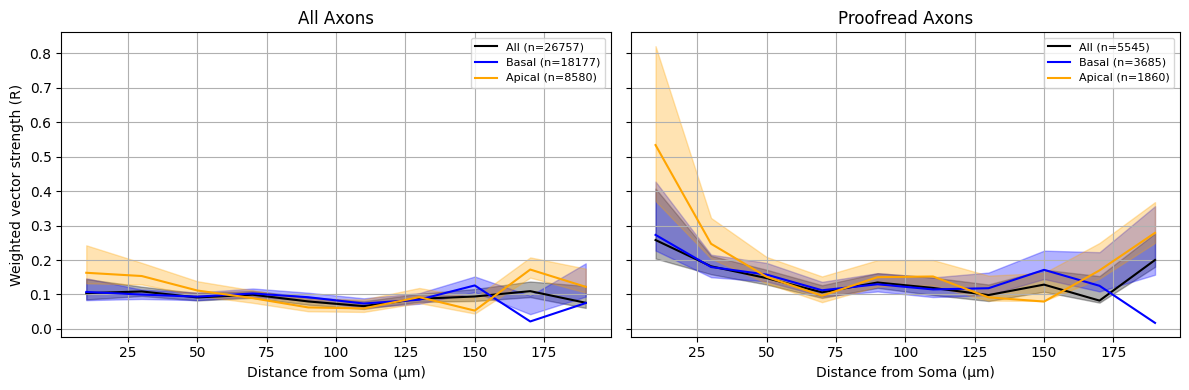

In [16]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.arange(0, 201, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
colors = {'All': 'black', 'Basal': 'blue', 'Apical': 'orange'}

def binned_vector_strength_weighted_with_ci(x, angles, weights, bins, n_bootstrap=500, seed=0):
    rng = np.random.default_rng(seed)

    x = np.asarray(x)
    angles = np.asarray(angles)
    weights = np.asarray(weights)

    valid = np.isfinite(x) & np.isfinite(angles) & np.isfinite(weights)
    x, angles, weights = x[valid], angles[valid], weights[valid]

    digitized = np.digitize(x, bins)
    means, lows, highs = [], [], []

    for i in range(1, len(bins)):
        mask = digitized == i
        if mask.sum() > 0:
            w = weights[mask]
            a = angles[mask]

            # Weighted resultant length for ORIENTATION (pi-periodic): exp(2j*a)
            vec = w * np.exp(2j * a)
            R = np.abs(np.sum(vec)) / np.sum(w)
            means.append(R)

            # Bootstrap IQR
            boot_Rs = []
            n = len(a)
            for _ in range(n_bootstrap):
                idx = rng.integers(0, n, size=n)
                ww = w[idx]
                aa = a[idx]
                boot_vec = ww * np.exp(2j * aa)
                boot_R = np.abs(np.sum(boot_vec)) / np.sum(ww)
                boot_Rs.append(boot_R)

            lows.append(np.percentile(boot_Rs, 25))
            highs.append(np.percentile(boot_Rs, 75))
        else:
            means.append(np.nan); lows.append(np.nan); highs.append(np.nan)

    return np.array(means), np.array(lows), np.array(highs)

def plot_vec_strength(ax, dfg, label, color, seed=0):
    # counts in legend should reflect valid rows
    dfg2 = dfg[
        dfg["distance_from_soma"].notna()
        & dfg["pref_ori_diff_wrapped"].notna()
        & dfg["size"].notna()
    ].copy()

    x = dfg2["distance_from_soma"].to_numpy()
    ang = dfg2["pref_ori_diff_wrapped"].to_numpy()
    w = (dfg2["size"] / dfg2["size"].mean()).to_numpy()  # normalized size weights

    m, lo, hi = binned_vector_strength_weighted_with_ci(x, ang, w, bins, n_bootstrap=500, seed=seed)
    ax.plot(bin_centers, m, color=color, label=f"{label} (n={len(dfg2)})")
    ax.fill_between(bin_centers, lo, hi, color=color, alpha=0.3)

# ---- base filtering ----
d0 = df.copy()
d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]     # no autapses
d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]                 # dendrites only

mask_proof = (
    d0["strat_axon_pre"].notna()
    & (d0["strat_axon_pre"].astype(str).str.lower().str.strip() != "none")
)

panels = [("All Axons", d0), ("Proofread Axons", d0[mask_proof])]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for j, (ax, (title, dpanel)) in enumerate(zip(axs, panels)):
    plot_vec_strength(ax, dpanel, "All", colors["All"], seed=10+j)
    plot_vec_strength(ax, dpanel[dpanel["type"].isin([3, 3.0])], "Basal", colors["Basal"], seed=20+j)
    plot_vec_strength(ax, dpanel[dpanel["type"].isin([4, 4.0])], "Apical", colors["Apical"], seed=30+j)

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("Distance from Soma (µm)")
    ax.legend(fontsize=8)

axs[0].set_ylabel("Weighted vector strength (R)")
plt.tight_layout()
plt.show()


# Circular mean weigthed

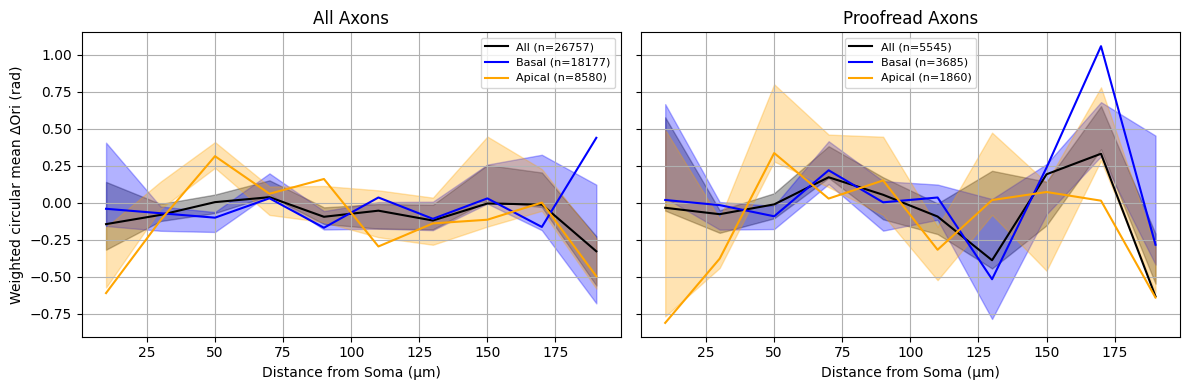

In [17]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.arange(0, 201, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
colors = {"All": "black", "Basal": "blue", "Apical": "orange"}

# ---- base filtering ----
d0 = df.copy()
d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]     # no autapses
d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]                 # dendrites only

# use signed wrapped delta
d0["delta_ori"] = d0["pref_ori_diff_wrapped"]

# proofread axon mask
mask_proof = (
    d0["strat_axon_pre"].notna()
    & (d0["strat_axon_pre"].astype(str).str.lower().str.strip() != "none")
)

def label_with_n(name, arr):
    return f"{name} (n={len(arr.dropna())})"

def plot_weighted_circ(ax, dfg, label, color):
    # keep only valid triplets
    dfg2 = dfg[
        dfg["distance_from_soma"].notna()
        & dfg["delta_ori"].notna()
        & dfg["size"].notna()
    ].copy()

    x = dfg2["distance_from_soma"].to_numpy()
    ang = dfg2["delta_ori"].to_numpy()
    w = dfg2["size"].to_numpy()

    m, lo, hi = binned_circular_mean_weighted(x, ang, w, bins)
    ax.plot(bin_centers, m, color=color, label=label_with_n(label, dfg2["delta_ori"]))
    ax.fill_between(bin_centers, lo, hi, alpha=0.3, color=color)

panels = [("All Axons", d0), ("Proofread Axons", d0[mask_proof])]

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, (title, dpanel) in zip(axs, panels):
    plot_weighted_circ(ax, dpanel, "All", colors["All"])
    plot_weighted_circ(ax, dpanel[dpanel["type"].isin([3, 3.0])], "Basal", colors["Basal"])
    plot_weighted_circ(ax, dpanel[dpanel["type"].isin([4, 4.0])], "Apical", colors["Apical"])

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("Distance from Soma (µm)")
    ax.legend(fontsize=8)

axs[0].set_ylabel("Weighted circular mean ΔOri (rad)")
plt.tight_layout()
plt.show()


# Modulus rather t han angle

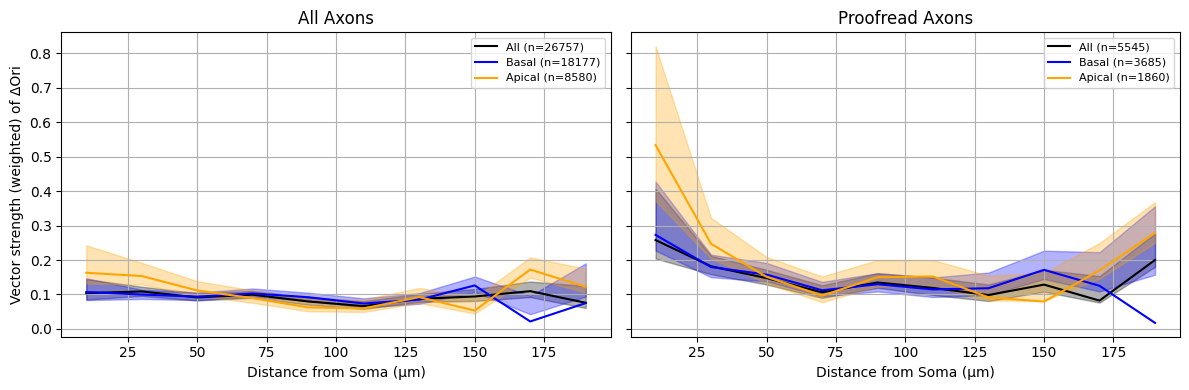

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Config
# ---------------------------------
bins = np.arange(0, 201, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
colors = {'All': 'black', 'Basal': 'blue', 'Apical': 'orange'}

# ---------------------------------
# Helper: vector strength with bootstrap IQR
# ---------------------------------
def binned_vector_strength_weighted_with_ci(x, angles, weights, bins, n_bootstrap=500, seed=0):
    rng = np.random.default_rng(seed)

    x = np.asarray(x)
    angles = np.asarray(angles)
    weights = np.asarray(weights)

    valid = np.isfinite(x) & np.isfinite(angles) & np.isfinite(weights)
    x, angles, weights = x[valid], angles[valid], weights[valid]

    digitized = np.digitize(x, bins)
    means, lows, highs = [], [], []

    for i in range(1, len(bins)):
        mask = digitized == i
        if mask.sum() > 0:
            w = weights[mask]
            a = angles[mask]

            # orientation periodicity => exp(2j*a)
            vec = w * np.exp(2j * a)
            R = np.abs(np.sum(vec)) / np.sum(w)
            means.append(R)

            boot_Rs = []
            n = len(a)
            for _ in range(n_bootstrap):
                idx = rng.integers(0, n, size=n)
                ww = w[idx]
                aa = a[idx]
                boot_vec = ww * np.exp(2j * aa)
                boot_R = np.abs(np.sum(boot_vec)) / np.sum(ww)
                boot_Rs.append(boot_R)

            lows.append(np.percentile(boot_Rs, 25))
            highs.append(np.percentile(boot_Rs, 75))
        else:
            means.append(np.nan); lows.append(np.nan); highs.append(np.nan)

    return np.array(means), np.array(lows), np.array(highs)

def label_with_n(name, dfg):
    return f"{name} (n={len(dfg)})"

def plot_vec_strength(ax, dfg, name, color, seed):
    dfg2 = dfg[
        dfg["distance_from_soma"].notna()
        & dfg["pref_ori_diff_wrapped"].notna()
        & dfg["size"].notna()
    ].copy()

    x = dfg2["distance_from_soma"].to_numpy()
    a = dfg2["pref_ori_diff_wrapped"].to_numpy()
    w = (dfg2["size"] / dfg2["size"].mean()).to_numpy()

    m, lo, hi = binned_vector_strength_weighted_with_ci(x, a, w, bins, n_bootstrap=500, seed=seed)
    ax.plot(bin_centers, m, color=color, label=label_with_n(name, dfg2))
    ax.fill_between(bin_centers, lo, hi, alpha=0.3, color=color)

# ---------------------------------
# Data + masks
# ---------------------------------
d0 = df.copy()
d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]     # no autapses
d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]                 # dendrites only

mask_proof = (
    d0["strat_axon_pre"].notna()
    & (d0["strat_axon_pre"].astype(str).str.lower().str.strip() != "none")
)

panels = [("All Axons", d0), ("Proofread Axons", d0[mask_proof])]

# ---------------------------------
# Plot
# ---------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for j, (ax, (title, dpanel)) in enumerate(zip(axs, panels)):
    plot_vec_strength(ax, dpanel, "All", colors["All"], seed=10+j)
    plot_vec_strength(ax, dpanel[dpanel["type"].isin([3, 3.0])], "Basal", colors["Basal"], seed=20+j)
    plot_vec_strength(ax, dpanel[dpanel["type"].isin([4, 4.0])], "Apical", colors["Apical"], seed=30+j)

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlabel("Distance from Soma (µm)")
    ax.legend(fontsize=8)

axs[0].set_ylabel("Vector strength (weighted) of ΔOri")
plt.tight_layout()
plt.show()


# Visualize full distribution

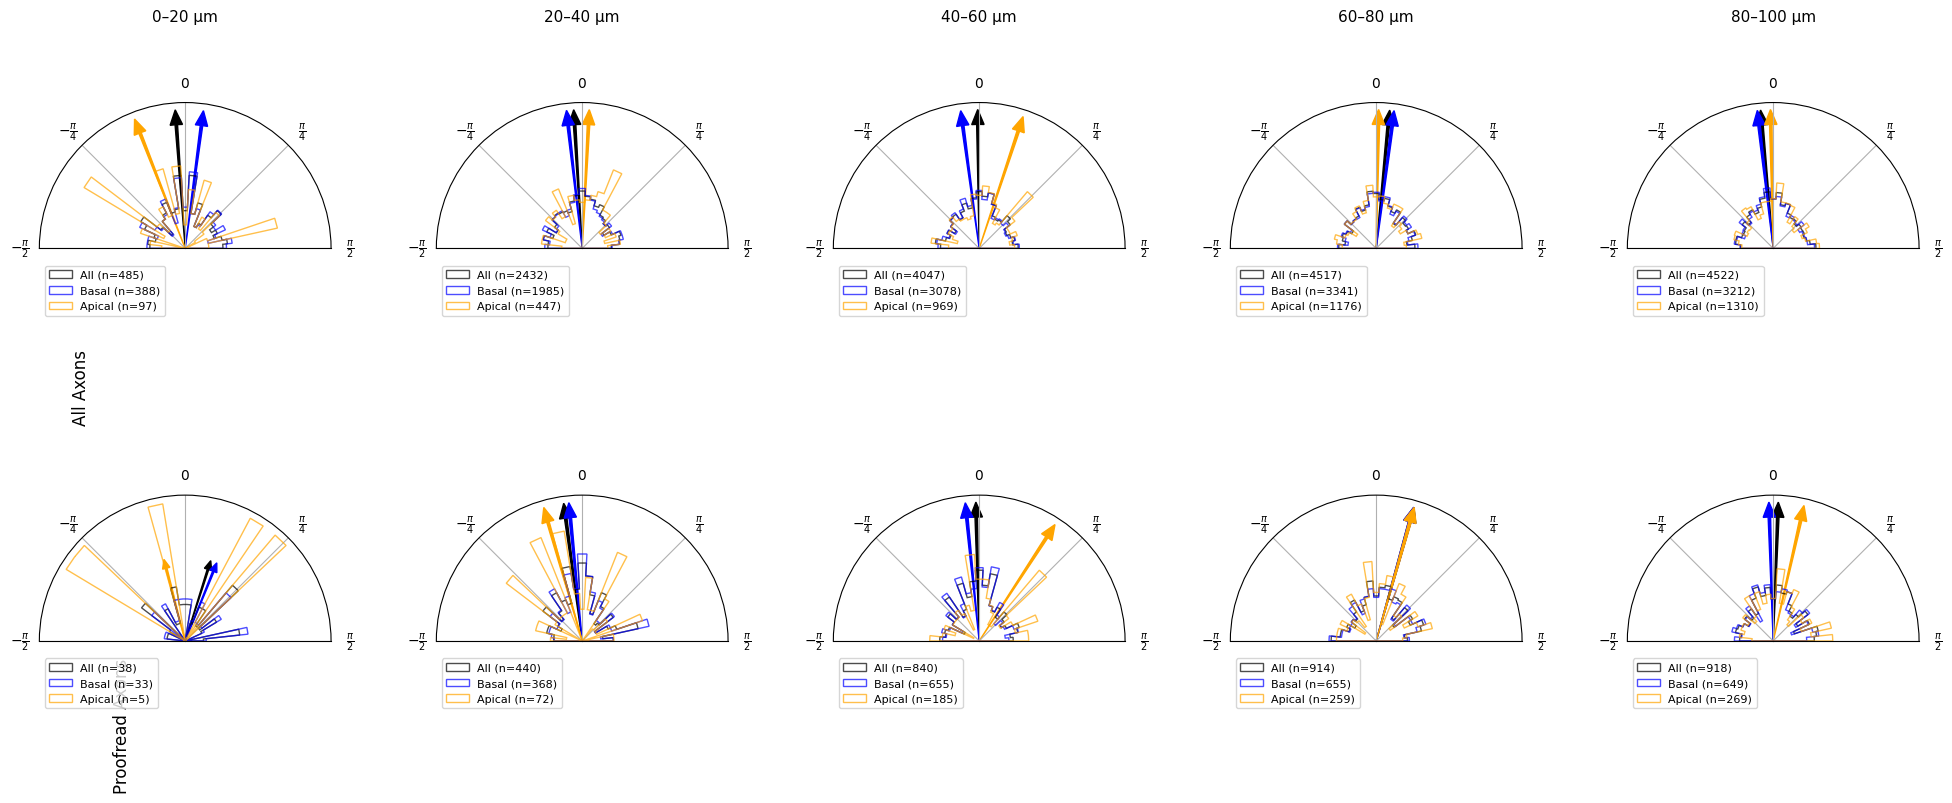

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Config (edit as you like)
# ----------------------------
bins_dist = np.arange(0, 101, 20)  # his example: 0-100
# bins_dist = np.arange(0, 201, 20)  # if you want 0-200 like other plots
bins_angle = np.linspace(-np.pi/2, np.pi/2, 30)

tick_locs = np.linspace(-np.pi/2, np.pi/2, 5)
tick_labels = [r"$-\frac{\pi}{2}$", r"$-\frac{\pi}{4}$", r"$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$"]

colors = {"All": "black", "Basal": "blue", "Apical": "orange"}

def circular_mean_ori(angles):
    angles = np.asarray(angles)
    angles = angles[np.isfinite(angles)]
    if len(angles) == 0:
        return np.nan
    return np.angle(np.mean(np.exp(2j * angles))) / 2

# ----------------------------
# Base filtering
# ----------------------------
d0 = df.copy()
d0 = d0[d0["pre_pt_root_id"] != d0["post_pt_root_id"]]
d0 = d0[d0["type"].isin([3, 3.0, 4, 4.0])]
d0 = d0[d0["distance_from_soma"].notna() & d0["pref_ori_diff_wrapped"].notna()]

mask_proof = (
    d0["strat_axon_pre"].notna()
    & (d0["strat_axon_pre"].astype(str).str.lower().str.strip() != "none")
)

rows = [
    ("All Axons", d0),
    ("Proofread Axons", d0[mask_proof]),
]

# ----------------------------
# Plot grid
# ----------------------------
n_bins = len(bins_dist) - 1
fig, axs = plt.subplots(
    2, n_bins,
    subplot_kw={"projection": "polar"},
    figsize=(4 * n_bins, 8)
)

for i in range(n_bins):
    dmin, dmax = bins_dist[i], bins_dist[i + 1]

    for row_idx, (row_name, drow) in enumerate(rows):
        ax = axs[row_idx, i]

        # Slice by distance
        ds = drow[(drow["distance_from_soma"] >= dmin) & (drow["distance_from_soma"] < dmax)]

        # Groups
        ang_all = ds["pref_ori_diff_wrapped"].dropna().to_numpy()
        ang_basal = ds[ds["type"].isin([3, 3.0])]["pref_ori_diff_wrapped"].dropna().to_numpy()
        ang_apical = ds[ds["type"].isin([4, 4.0])]["pref_ori_diff_wrapped"].dropna().to_numpy()

        # Hist overlays (density)
        ax.hist(ang_all, bins=bins_angle, density=True, histtype="step", color=colors["All"], alpha=0.7)
        ax.hist(ang_basal, bins=bins_angle, density=True, histtype="step", color=colors["Basal"], alpha=0.7)
        ax.hist(ang_apical, bins=bins_angle, density=True, histtype="step", color=colors["Apical"], alpha=0.7)

        # Mean arrows (radius 1)
        for angs, col in [(ang_all, colors["All"]), (ang_basal, colors["Basal"]), (ang_apical, colors["Apical"])]:
            if len(angs) > 0:
                m = circular_mean_ori(angs)
                if np.isfinite(m):
                    ax.arrow(m, 0, 0, 1, width=0.02, head_length=0.12, head_width=0.10, color=col)

        # Polar formatting to match his half-dome
        ax.set_thetamin(-90)
        ax.set_thetamax(90)
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_rticks([])
        ax.set_xticks(tick_locs)
        ax.set_xticklabels(tick_labels)

        # Legends with n
        ax.legend(
            [
                f"All (n={len(ang_all)})",
                f"Basal (n={len(ang_basal)})",
                f"Apical (n={len(ang_apical)})",
            ],
            fontsize=8,
            loc="lower left",
        )

        # Column titles
        if row_idx == 0:
            ax.set_title(f"{dmin}–{dmax} µm", fontsize=11)

        # Row labels on left
        if i == 0:
            ax.text(
                -2.5, 1.4, row_name,
                va="center", ha="center",
                rotation=90, fontsize=12
            )

plt.tight_layout()
plt.show()
